# Transformer pipeline: coin and flower processes

The transformer counterpart of `updated_pipeline_asymmetric_process.ipynb` (the GRU). Samplers, closed forms and true ε-machines come from `processes.py`, the model (`DiscreteCausalDecoder`, a K-way straight-through bottleneck whose argmax *is* the causal state) from `models.py`, training from `training.py`, extractors from `extraction.py`. This notebook holds only the configuration, the process spec built from it, and the plots.

Each run trains one **arm** — forward (tril mask, predicts the next token; compared with C+, `occ_fw`, `T_theory_fw`) or backward (triu mask, predicts the previous token; compared with C−, `occ_bw`, `T_theory_bw`) — reads the states off the bottleneck, extracts the free-running state-to-state matrix and an empirical symbolic machine, and scores everything against the closed forms. Cross-entropies are in **bits/token**.

## 1. Setup

Configuration, then the helpers: process spec (theory for both arms), extraction helpers, `run_pipeline`, plots. `resolve_cfg` sets V, K = 4V and S = V per process; every run prints the configuration it trains under as its first line.

In [21]:

import os
import math
import time
import random
import copy
from dataclasses import dataclass, asdict, replace
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.utils.data as tud

# Everything that defines the experiment lives in the modules; this notebook only configures, runs and plots.
from processes import (SequenceDataset, generate, make_dice, true_machine, entropy_bits,
                       coin_complexity, flower_complexity,
                       entropy_rate_coin, flower_entropy_rate,
                       causal_state_count, causal_state_occupancy,
                       coin_transition_matrix, coin_rev_transition_matrix,
                       flower_transition_matrix, flower_rev_transition_matrix,
                       coin_tag, flower_tag)
from models import DiscreteCausalDecoder                         # built by training.train_model
from training import (train_model, split_loader, eval_ce, set_seed, to_cpu_for_analysis,
                      diagnose_divergence, cleanup, quiet)
from extraction import (causal_state_report, transition_matrix_extraction,
                        match_permutation, compare_transition_matrix)
from schedules import parse_tau, parse_lr

print(f"Torch version: {torch.__version__}")
print(f"Accelerators: cuda={torch.cuda.is_available()}  mps={torch.backends.mps.is_available()}")

Torch version: 2.12.1
Accelerators: cuda=False  mps=True


In [22]:

@dataclass
class ExperimentConfig:
    # --- Process parameters: run_pipeline(cfg, process, mode) with process in {"coin", "flower"} ---
    # coin: hidden coin 0 -> 1 w.p. p, 1 -> 0 w.p. q; tokens {0, 1, 2}
    asym_p: float = 0.70
    asym_q: float = 0.80
    coin_burn_in: int = 200

    # flower: n dice with m faces; tokens 0..n-1 select a die, n..n+m-1 are its roll
    flower_n: int = 3
    flower_m: int = 8
    flower_dice_seed: int = 0      # the dice DEFINE the flower process, so they get their own seed
    flower_burn_in: int = 4        # iid across cycles, so the burn-in is belt-and-braces

    data_seed: int = 1             # rng handed to processes.generate

    # --- Data: num_samples sequences of seq_len tokens (processes.SequenceDataset), every token trained on ---
    seq_len: int = 300             # also the transformer's context (max_len) and the free-running window
    num_samples: int = 1000
    batch_size: int = 32
    test_ratio: float = 0.20       # seeded split, training.split_loader

    # --- Model (models.py) ---
    # V (vocabulary), K (discrete-state budget) and S (state_dim) follow the process:
    # V = 3 for coin, n + m for flower, K = num_states_mult * V, S = state_dim_mult * V.
    # All three are resolved per run by resolve_cfg below; the values here are the coin ones.
    d_model: int = 32
    n_layers: int = 4
    num_states_mult: int = 4       # K is a state BUDGET, not an estimate: the bottleneck needs slack
    state_dim_mult: int = 1        # S carries no expressive power (state_matrix @ emission is one (K,V) map)
    num_states: int = 12
    state_dim: int = 3
    symbol_vocab_size: int = 3
    tau: float | str = "const:1"         # straight-through temperature: a float, "const:X" or "geom:A:B" (schedules.py)
    usage_beta: Optional[float] = None   # None -> 1 / (batch_size * seq_len); models.DiscreteCausalDecoder.usage_penalty

    # --- Training (training.py -> lightning) ---
    max_epochs: int = 150
    learning_rate: float = 1e-3
    lr_schedule: str = "const"     # opt-in "cos:MIN" / "cos:MIN:HOLD" (schedules.parse_lr); see section 6
    weight_decay: float = 0.01     # what keeps the deterministic transitions from diverging (models._Decoder.configure_optimizers)
    accelerator: str = "auto"      # "auto" picks MPS on a Mac (fast, not bit-reproducible); "cpu" is exactly repeatable
    val_every_n_steps: int = 25
    restore_best: bool = True      # hand back the weights at the best validation CE, as the GRU notebook does
    fresh_samples: int = 100       # fresh sequences drawn for an unbiased CE (the checkpoint is selected on the test split)
    quiet_training: bool = True    # swallow Lightning's per-model chatter (re-emitted if training raises)

    # --- Extraction (extraction.py) ---
    ana_batch: int = 32
    state_min_pos: int = 5         # drop the short-context end of each sequence when reading states
    conv_tol: float = 0.10         # |CE - H_inf| (bits) above this = not converged
    trans_total_run: int = 5000    # free-running generation steps for the state-transition matrix

    random_seed: int = 0           # split + initialisation

def resolve_cfg(cfg: ExperimentConfig, num_token: int) -> ExperimentConfig:
    """One cfg per run: V is the process's token count, K = num_states_mult * V and
    S = state_dim_mult * V.  usage_beta = 1/(batch * seq_len) unless set explicitly --
    it must stay under the optimisation cliff (~6e-4 at lr 1e-3) above which the
    bottleneck collapses to one state, and the cliff moves with batch and seq_len."""
    V = int(num_token)
    beta = (1.0 / (cfg.batch_size * cfg.seq_len) if cfg.usage_beta is None
            else float(cfg.usage_beta))
    return replace(cfg, symbol_vocab_size=V, num_states=cfg.num_states_mult * V,
                   state_dim=cfg.state_dim_mult * V, usage_beta=beta)

def config_line(cfg: ExperimentConfig, process: str = "", mode: str = "") -> str:
    """One line saying what a run trains under; run_pipeline prints it first."""
    head = " | ".join(x for x in (process, mode) if x)
    return (f"[{head}] {cfg.num_samples} x {cfg.seq_len} tokens, batch {cfg.batch_size} | "
            f"d_model {cfg.d_model}, {cfg.n_layers} layers, K = {cfg.num_states_mult}V, S = {cfg.state_dim_mult}V | "
            f"tau {cfg.tau} | lr {cfg.learning_rate:g} ({cfg.lr_schedule}), wd {cfg.weight_decay:g}, "
            f"{cfg.max_epochs} epochs | {'best-val checkpoint' if cfg.restore_best else 'final weights'} | seed {cfg.random_seed}")

cfg = ExperimentConfig()
set_seed(cfg.random_seed)
parse_tau(cfg.tau)                 # validate the schedules now, not a minute into the first fit
parse_lr(cfg.lr_schedule, cfg.learning_rate)

print(config_line(cfg))
print(pd.Series(asdict(cfg)).to_string())

[] 1000 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau const:1 | lr 0.001 (const), wd 0.01, 150 epochs | best-val checkpoint | seed 0
asym_p                   0.7
asym_q                   0.8
coin_burn_in             200
flower_n                   3
flower_m                   8
flower_dice_seed           0
flower_burn_in             4
data_seed                  1
seq_len                  300
num_samples             1000
batch_size                32
test_ratio               0.2
d_model                   32
n_layers                   4
num_states_mult            4
state_dim_mult             1
num_states                12
state_dim                  3
symbol_vocab_size          3
tau                  const:1
usage_beta              None
max_epochs               150
learning_rate          0.001
lr_schedule            const
weight_decay            0.01
accelerator             auto
val_every_n_steps         25
restore_best            True
fresh_samples            100
quie

In [23]:

ARM = {"forward": "fw", "backward": "bw"}

def process_spec(cfg: ExperimentConfig, process: str) -> Dict:
    """Everything the pipeline needs to know about the chosen process, for BOTH arms,
    from the notebook cfg alone.

    The sampler parameters and every closed form (entropy rate, C+/C-, causal-state
    counts, stationary occupancies, state-transition matrices and the true
    epsilon-machines with emissions) come from processes.py, so the data and the
    theory it is compared against are computed from the same numbers.

    Vocabulary:  coin  V = 3,   flower  V = n + m.
    """
    if process == "coin":
        p, q = cfg.asym_p, cfg.asym_q
        params = {"p": p, "q": q}
        C_plus, C_minus = coin_complexity(p, q)
        spec = {
            "kind": "coin", "tag": coin_tag(p, q), "params": params,
            "num_token": 3, "burn_in": cfg.coin_burn_in,
            "entropy_rate": entropy_rate_coin(p, q),          # bits/token, both arms
            "C_plus": C_plus, "C_minus": C_minus,
            "true_k_fw": causal_state_count("coin", "forward"),
            "true_k_bw": causal_state_count("coin", "backward"),
            "occ_fw": causal_state_occupancy("coin", "forward",  p=p, q=q),
            "occ_bw": causal_state_occupancy("coin", "backward", p=p, q=q),
            "T_theory_fw": coin_transition_matrix(p, q),
            "T_theory_bw": coin_rev_transition_matrix(p, q),
        }
    elif process == "flower":
        n, m = cfg.flower_n, cfg.flower_m
        dice = make_dice(n, m, cfg.flower_dice_seed)
        params = {"n": n, "m": m, "dice_probs": dice}
        C_plus, C_minus = flower_complexity(n, m, dice)
        spec = {
            "kind": "flower", "tag": flower_tag(n, m), "params": params,
            "num_token": n + m, "burn_in": cfg.flower_burn_in,
            "entropy_rate": flower_entropy_rate(n, m, dice),  # bits/token, both arms
            "C_plus": C_plus, "C_minus": C_minus,
            "true_k_fw": causal_state_count("flower", "forward", n=n, m=m),
            "true_k_bw": causal_state_count("flower", "backward", n=n, m=m, dice_probs=dice),
            "occ_fw": causal_state_occupancy("flower", "forward", n=n),
            "occ_bw": causal_state_occupancy("flower", "backward", n=n, m=m, dice_probs=dice),
            "T_theory_fw": flower_transition_matrix(n),
            "T_theory_bw": flower_rev_transition_matrix(n, m, dice),
        }
    else:
        raise ValueError(f"unknown process {process!r}; expected 'coin' or 'flower'")

    # The true epsilon-machines in (next_state, emission_probs) form, one per arm.
    spec["true_machine_fw"] = true_machine(spec["kind"], params, "forward")
    spec["true_machine_bw"] = true_machine(spec["kind"], params, "backward")
    return spec

def theory_for_arm(spec: Dict, mode: str) -> Dict:
    """The closed forms the model in this arm is compared against."""
    arm = ARM[mode]
    return {
        "arm": arm, "names": state_names(spec, mode),
        "C": spec["C_plus"] if arm == "fw" else spec["C_minus"],
        "true_k": spec[f"true_k_{arm}"],
        "occupancy": spec[f"occ_{arm}"],
        "T_theory": spec[f"T_theory_{arm}"],
        "true_machine": spec[f"true_machine_{arm}"],
    }

def state_names(spec: Dict, mode: str) -> List[str]:
    """Names of the theoretical states in the order of causal_state_occupancy / true_machine."""
    if spec["kind"] == "coin":
        return ["tails", "heads"] if mode == "forward" else ["tok 0", "tok 1", "tok 2"]
    n = spec["params"]["n"]
    if mode == "forward":
        return ["R"] + [f"die {i}" for i in range(n)]
    return ["S"] + [f"class {c}" for c in range(spec["true_k_bw"] - 1)]

def machine_state_transition(machine: Dict[str, np.ndarray]) -> np.ndarray:
    """(K, K) state-to-state matrix induced by an emission-labelled machine."""
    next_state = np.asarray(machine["next_state"], dtype=np.int64)
    emission_probs = np.asarray(machine["emission_probs"], dtype=np.float64)
    num_states = next_state.shape[0]
    T = np.zeros((num_states, num_states), dtype=np.float64)
    for s in range(num_states):
        for x in range(emission_probs.shape[1]):
            T[s, int(next_state[s, x])] += float(emission_probs[s, x])
    return T

def stationary_distribution_from_machine(machine: Dict[str, np.ndarray]) -> np.ndarray:
    T = machine_state_transition(machine)
    num_states = T.shape[0]
    A = T.T - np.eye(num_states)
    A[-1, :] = 1.0
    b = np.zeros(num_states, dtype=np.float64)
    b[-1] = 1.0
    pi = np.linalg.solve(A, b)
    pi = np.clip(pi, 0.0, None)
    pi /= max(pi.sum(), 1e-12)
    return pi

def true_state_from_past(true_machine_: Dict[str, np.ndarray], past_seq: np.ndarray) -> int:
    """Causal state after a past window.  Every true machine is synchronised by the last
    symbol, so it is next_state[., last symbol], the same for every row."""
    return int(true_machine_["next_state"][0, int(past_seq[-1])])

In [24]:

def arm_inputs(seqs: np.ndarray, mode: str) -> np.ndarray:
    """The tokens a model of this arm sees, in its own alignment (models._Decoder._split):
    x[:-1] forward, x[1:] backward."""
    seqs = np.asarray(seqs, dtype=np.int64)
    return seqs[:, :-1] if mode == "forward" else seqs[:, 1:]

@torch.no_grad()
def hard_state_trajectories(model, loader):
    """(states, tokens), (N, T) each: the bottleneck state and the model's input token at
    every position, in the arm's own alignment.  Discrete model only."""
    model.eval()
    device = next(model.parameters()).device
    states, tokens = [], []
    for batch in loader:
        inputs, _ = model._split(batch, model.mode)
        model(inputs.to(device))
        states.append(model.last_states.detach().cpu().numpy())
        tokens.append(inputs.detach().cpu().numpy())
    return np.concatenate(states, axis=0), np.concatenate(tokens, axis=0)

def kept_positions(mode: str, T: int, min_pos: int) -> slice:
    """extraction.causal_state_report's rule: drop the short-context end of each sequence,
    which is the START of a forward model and the FINISH of a backward one."""
    return slice(min_pos, None) if mode == "forward" else slice(0, max(T - min_pos, 1))

def empirical_symbolic_machine(model, loader, min_pos: int) -> Dict:
    """The unifilar machine the discrete model has BECOME, read off its state trajectories.

    A transformer's state is a function of the whole context, so this is an estimate:
    next_state[s, x] is the majority successor of (state s, token x) and determinism[s, x]
    the fraction of visits that agree with it -- 1 everywhere for a genuinely unifilar
    machine.  Forward the step is (s_t, x_{t+1}) -> s_{t+1}; backward it is one step back
    in time, (s_t, x_{t-1}) -> s_{t-1}, matching processes.true_machine(..., "backward").
    emission_probs is model.emission_table() over the visited states, which are relabelled
    0..k-1 (state_ids maps back to the bottleneck's indices, relabel the other way).
    """
    states, tokens = hard_state_trajectories(model, loader)
    K, V = int(model.n_states), int(model.token_size)
    keep = kept_positions(model.mode, states.shape[1], min_pos)
    states, tokens = states[:, keep], tokens[:, keep]

    if model.mode == "forward":
        s_from, x, s_to = states[:, :-1], tokens[:, 1:], states[:, 1:]
    else:
        s_from, x, s_to = states[:, 1:], tokens[:, :-1], states[:, :-1]
    triples = np.zeros((K, V, K), dtype=np.float64)
    np.add.at(triples, (s_from.ravel(), x.ravel(), s_to.ravel()), 1.0)

    counts = np.bincount(states.ravel(), minlength=K).astype(np.float64)
    visited = np.flatnonzero(counts > 0)
    relabel = np.full(K, -1, dtype=np.int64)
    relabel[visited] = np.arange(len(visited))

    k = len(visited)
    next_state = np.zeros((k, V), dtype=np.int64)
    determinism = np.full((k, V), np.nan)
    for i, s in enumerate(visited):
        for symbol in range(V):
            row = triples[s, symbol]
            if row.sum() > 0:
                j = int(row.argmax())
                next_state[i, symbol] = relabel[j]
                determinism[i, symbol] = row[j] / row.sum()
            else:
                next_state[i, symbol] = i          # (s, x) never observed: a self-loop under a ~0 emission
    emission_probs = model.emission_table().detach().cpu().numpy()[visited]

    return {
        "next_state": next_state, "emission_probs": emission_probs,
        "determinism": determinism, "state_ids": visited, "relabel": relabel,
        "counts": counts[visited], "init_probs": counts[visited] / counts[visited].sum(),
        "pair_counts": triples[visited].sum(axis=-1),
    }

def symbolic_cross_entropy(machine: Dict, tokens: np.ndarray, start_states, mode: str, t0: int) -> float:
    """Bits/token of a unifilar machine run along the arm over the model's input tokens,
    started from start_states at position t0: forward over positions t0+1.., backward
    over t0-1..0.  The same scorer serves the empirical machine and the true one."""
    next_state = np.asarray(machine["next_state"], dtype=np.int64)
    emission_probs = np.asarray(machine["emission_probs"], dtype=np.float64)
    total_bits, total_steps = 0.0, 0
    for row, s0 in zip(tokens, start_states):
        s = int(s0)
        path = row[t0 + 1:] if mode == "forward" else row[:t0][::-1]
        for x in path:
            total_bits -= math.log2(max(float(emission_probs[s, int(x)]), 1e-12))
            s = int(next_state[s, int(x)])
            total_steps += 1
    return total_bits / max(total_steps, 1)

In [25]:

def run_pipeline(cfg, process, mode="forward"):
    """One process x one arm of the discrete transformer (models.DiscreteCausalDecoder),
    on the notebook's config.

    mode  "forward"   tril mask, predicts the next token;     compared with C+, occ_fw, T_theory_fw
          "backward"  triu mask, predicts the previous token; compared with C-, occ_bw, T_theory_bw
    """
    if mode not in ARM:
        raise ValueError(f"mode must be 'forward' or 'backward', got {mode!r}")
    spec = process_spec(cfg, process)
    # One cfg per run: V = spec["num_token"], K = num_states_mult * V, S = state_dim_mult * V.
    cfg = resolve_cfg(cfg, spec["num_token"])
    th = theory_for_arm(spec, mode)
    H = spec["entropy_rate"]
    print(config_line(cfg, spec["tag"], mode))

    print(f"\n==== 1) Generate observable data ({spec['tag']} | {mode} arm) ====")
    ds = SequenceDataset(generate(spec["kind"], spec["params"], cfg.num_samples, cfg.seq_len,
                                  spec["burn_in"], np.random.default_rng(cfg.data_seed)))
    # One seeded split, so both arms on this cfg see the same hold-out set.
    train_loader, test_loader = split_loader(ds, cfg.batch_size, cfg.test_ratio, seed=cfg.random_seed)
    ana_loader = tud.DataLoader(ds, batch_size=cfg.ana_batch, shuffle=False)
    test_indices = np.asarray(test_loader.dataset.indices)
    print(f"Vocabulary size V: {cfg.symbol_vocab_size} | state budget K: {cfg.num_states} | "
          f"state_dim S: {cfg.state_dim} | usage_beta: {cfg.usage_beta:.2e} | tau: {cfg.tau!r} | "
          f"lr: {cfg.learning_rate:g} ({cfg.lr_schedule})")
    print(f"Sequences: {len(ds):,} x {ds.seq_len} scored tokens | "
          f"train {len(train_loader.dataset):,} / test {len(test_indices):,}")
    print(f"Closed forms: H_inf = {H:.4f} bits | C+ = {spec['C_plus']:.4f} | C- = {spec['C_minus']:.4f} | "
          f"true k = {spec['true_k_fw']} fw / {spec['true_k_bw']} bw | this arm: C = {th['C']:.4f}, k = {th['true_k']}")

    print(f"\n==== 2) Train the discrete transformer ({mode}) ====")
    set_seed(cfg.random_seed)
    torch.manual_seed(cfg.random_seed * 1000)
    t_start = time.time()
    with quiet(cfg.quiet_training):
        rec = train_model(
            train_loader, "discrete", val_loader=test_loader,
            num_token=cfg.symbol_vocab_size, d_model=cfg.d_model, max_len=ds.seq_len,
            max_epochs=cfg.max_epochs, lr=cfg.learning_rate, mode=mode, n_layers=cfg.n_layers,
            weight_decay=cfg.weight_decay, accelerator=cfg.accelerator,
            val_every_n_steps=cfg.val_every_n_steps,
            n_states=cfg.num_states, state_dim=cfg.state_dim, tau=cfg.tau, usage_beta=cfg.usage_beta,
            lr_schedule=cfg.lr_schedule, restore_best=cfg.restore_best,
        )
    model = to_cpu_for_analysis(rec.model)
    n_params = sum(p.numel() for p in model.parameters())
    n_steps = len(rec.step_loss)
    print(f"Trained {type(model).__name__} ({n_params:,} parameters) in {time.time() - t_start:.0f} s, "
          f"{n_steps} gradient steps")
    if rec.restored_best:
        print(f"Restored the best-validation checkpoint: step {rec.best_step} of {n_steps} "
              f"(fraction {rec.best_step / max(n_steps, 1):.2f}), validation CE {rec.best_val:.6f} bits")
    else:
        print("Kept the final weights (restore_best is off)")
    history = {
        "step_at": [int(v) for v in rec.step_at], "step_loss": [float(v) for v in rec.step_loss],
        "val_at": [int(v) for v in rec.step_val_at], "val_loss": [float(v) for v in rec.step_val_loss],
        "step_lr": [float(v) for v in rec.step_lr], "epoch_loss": [float(v) for v in rec.epoch_loss],
        "best_step": int(rec.best_step) if rec.restored_best else -1,
        "best_val": float(rec.best_val) if rec.restored_best else float("nan"),
    }

    print("\n==== 3) Evaluate against the entropy rate ====")
    test_ce, test_ppl = eval_ce(model, test_loader)
    divergence = diagnose_divergence(rec.step_loss)
    within_tol = bool(abs(test_ce - H) <= cfg.conv_tol)
    print(f"Test CE:      {test_ce:.6f} bits/token (perplexity {test_ppl:.4f})")
    print(f"H_inf:        {H:.6f} bits/token (closed form)")
    print(f"CE - H_inf:   {test_ce - H:+.6f}  -> {'converged' if within_tol else 'NOT converged'} "
          f"(conv_tol {cfg.conv_tol}){'  [DIVERGED after its minimum]' if divergence['diverged'] else ''}")
    # The checkpoint was selected on the test split, so its CE there is a selected quantity;
    # a fresh draw of the process (free: the process is known) gives an unbiased one.
    fresh = SequenceDataset(generate(spec["kind"], spec["params"], cfg.fresh_samples, cfg.seq_len,
                                     spec["burn_in"], np.random.default_rng(cfg.data_seed + 1000)))
    fresh_ce, _ = eval_ce(model, tud.DataLoader(fresh, batch_size=cfg.ana_batch, shuffle=False))
    print(f"Fresh-sequence CE ({cfg.fresh_samples} new sequences): {fresh_ce:.6f} bits/token "
          f"(gap {fresh_ce - H:+.6f})")
    # When were the states found?  The first validation point inside the H_inf band; the
    # fraction of the run it sits at is the hold an lr schedule should end at (or after).
    val_at, val_loss = np.asarray(history["val_at"]), np.asarray(history["val_loss"])
    inside = np.flatnonzero(np.abs(val_loss - H) <= cfg.conv_tol)
    found_at = int(val_at[inside[0]]) if inside.size else -1
    found_frac = found_at / max(n_steps, 1) if found_at >= 0 else float("nan")
    print(f"Validation CE first inside the H_inf band: "
          + (f"step {found_at} of {n_steps} (fraction {found_frac:.2f} of the run)" if found_at >= 0 else "never"))

    # The true machine scored on the held-out sequences, in this arm's direction.
    tokens_te = arm_inputs(ds.seqs[test_indices], mode)
    T = tokens_te.shape[1]
    t0 = cfg.state_min_pos if mode == "forward" else T - 1 - cfg.state_min_pos
    true_start = th["true_machine"]["next_state"][0, tokens_te[:, t0]]
    true_ce = symbolic_cross_entropy(th["true_machine"], tokens_te, true_start, mode, t0)
    print(f"True-machine CE on the test sequences: {true_ce:.6f} bits/token")

    print("\n==== 4) Read the causal states off the bottleneck ====")
    report = causal_state_report(model, ana_loader, min_pos=cfg.state_min_pos)
    report["S_emp"] = float(report["S_emp"]) + 0.0        # a single state gives -0.0
    print(f"States used: {report['n_states_used']} / {report['n_states']} (true {th['true_k']})")
    print(f"S_emp = {report['S_emp']:.6f} bits vs C = {th['C']:.6f} bits | "
          f"H(state | token) = {report['h_state_given_token']:.6f} bits")
    print("Learned occupancy (visited, sorted):", np.round(np.sort(report["occupancy"][report["occupied"]])[::-1], 4))
    print("Theory occupancy (sorted):          ", np.round(np.sort(np.asarray(th["occupancy"]))[::-1], 4))

    print("\n==== 5) Learned state-to-state transition matrix vs the closed form ====")
    # Free-running generation: for a backward model the matrix is one step back in time,
    # the convention of T_theory_bw (processes.*_rev_transition_matrix).
    T_learned = transition_matrix_extraction(
        model, spec["kind"], spec["params"], burn_in=cfg.seq_len + 50,
        total_run=cfg.trans_total_run, window_size=cfg.seq_len,
        rng=np.random.default_rng(cfg.random_seed))
    comparison = compare_transition_matrix(
        T_learned, th["T_theory"], report["emissions"], th["true_machine"]["emission_probs"],
        weights=report["occupancy"])
    groups = {th["names"][t]: members for t, members in comparison["groups"].items()}
    print(f"{comparison['n_visited']} states visited in generation, {th['true_k']} in theory")
    print(f"Learned -> theoretical states (by emission row): {groups}")
    print(f"max |T_learned - T_theory| = {comparison['max_error']:.4f} | mean = {comparison['mean_error']:.4f}"
          + (f" | theoretical states with no learned state: {[th['names'][t] for t in comparison['missing']]}"
             if comparison["missing"] else ""))
    if comparison["permutation"] is not None:
        print(f"(match_permutation, the F3 comparison: max err {comparison['permutation'][2]:.4f})")

    print("\n==== 6) Empirical symbolic machine from the state trajectories ====")
    machine = empirical_symbolic_machine(model, ana_loader, cfg.state_min_pos)
    det = machine["determinism"]
    det_mean = float(np.nanmean(det)) if np.isfinite(det).any() else float("nan")
    weighted = machine["pair_counts"] / machine["pair_counts"].sum()
    det_weighted = float(np.nansum(np.where(np.isfinite(det), det * weighted, 0.0)))
    minimal_stationary = stationary_distribution_from_machine(machine)
    print(f"Machine size: {machine['next_state'].shape[0]} (true {th['true_k']}) | "
          f"determinism of (state, token) -> state: mean {det_mean:.4f}, visit-weighted {det_weighted:.4f}")

    print("\n==== 7) Score the symbolic machine on the test sequences ====")
    states_te, _ = hard_state_trajectories(model, test_loader)
    symbolic_start = machine["relabel"][states_te[:, t0]]
    symbolic_ce = symbolic_cross_entropy(machine, tokens_te, symbolic_start, mode, t0)
    print(f"Symbolic-machine test CE: {symbolic_ce:.6f} bits/token | neural {test_ce:.6f} | "
          f"true machine {true_ce:.6f} | H_inf {H:.6f}")

    summary_table = pd.DataFrame({
        "Metric": [
            "Test CE (bits)", "Fresh-sequence CE (bits)", "Entropy rate H_inf (bits)", "CE - H_inf",
            "Converged (|CE - H_inf| <= conv_tol)", "Diverged after minimum",
            "Best-val checkpoint step (fraction of run)",
            "Val CE first in band (fraction of run)",
            "True-machine test CE (bits)", "Symbolic-machine test CE (bits)",
            "S_emp (bits)", "C (theory, bits)",
            "States used", "State budget K", "True machine size",
            "H(state | token) (bits)",
            "Transition max |err| (emission-matched)", "Transition mean |err|",
            "Theoretical states missing",
            "Symbolic machine determinism",
        ],
        "Value": [
            test_ce, fresh_ce, H, test_ce - H,
            within_tol, bool(divergence["diverged"]),
            (history["best_step"] / max(n_steps, 1)) if history["best_step"] >= 0 else float("nan"),
            found_frac,
            true_ce, symbolic_ce,
            report["S_emp"], th["C"],
            report["n_states_used"], report["n_states"], th["true_k"],
            report["h_state_given_token"],
            comparison["max_error"], comparison["mean_error"],
            len(comparison["missing"]),
            det_weighted,
        ],
    })

    return {
        "cfg": cfg, "process": process, "mode": mode, "spec": spec, "theory": th,
        "model": model, "history": history, "dataset": ds, "test_indices": test_indices,
        "train_loader": train_loader, "test_loader": test_loader, "ana_loader": ana_loader,
        "report": report, "raw_state_counts": report["counts"],
        "transition": T_learned, "transition_comparison": comparison,
        "machine": machine, "minimal_machine": machine, "minimal_stationary": minimal_stationary,
        "true_machine": th["true_machine"], "true_stationary": th["occupancy"],
        "summary_table": summary_table,
        "metrics": {
            "test_ce": test_ce, "test_ppl": test_ppl, "fresh_ce": fresh_ce, "entropy_rate": H, "gap": test_ce - H,
            "best_step": history["best_step"],
            "within_tol": within_tol, "diverged": bool(divergence["diverged"]),
            "found_at_step": found_at, "found_at_fraction": found_frac,
            "true_ce": true_ce, "symbolic_ce": symbolic_ce,
            "S_emp": report["S_emp"], "C": th["C"], "k": report["n_states_used"], "true_k": th["true_k"],
            "h_state_given_token": report["h_state_given_token"],
            "transition_max_err": comparison["max_error"], "transition_mean_err": comparison["mean_error"],
            "transition_missing": len(comparison["missing"]), "determinism": det_weighted,
        },
    }

def run_both_arms(cfg, process):
    """The forward and backward discrete models on the same realisation and hold-out split."""
    runs = {}
    for mode in ("forward", "backward"):
        print("\n" + "#" * 78 + f"\n# {process}: {mode}\n" + "#" * 78)
        runs[mode] = run_pipeline(cfg, process, mode=mode)
        cleanup()
    return runs

def arms_table(runs):
    """One row per arm: the extracted states and transition matrix against theory."""
    rows = []
    for mode, r in runs.items():
        m = r["metrics"]
        rows.append({
            "arm": mode, "test CE (bits)": m["test_ce"], "fresh CE": m["fresh_ce"], "H_inf": m["entropy_rate"],
            "converged": m["within_tol"], "best step": m["best_step"],
            "k found": m["k"], "true k": m["true_k"], "S_emp (bits)": m["S_emp"], "C (bits)": m["C"],
            "S_emp - C": m["S_emp"] - m["C"], "T max |err|": m["transition_max_err"],
            "T mean |err|": m["transition_mean_err"], "T states missing": m["transition_missing"],
        })
    return pd.DataFrame(rows)

In [26]:
_BLUE, _ORNG, _GREY, _INK = "#3B6EA5", "#C4703A", "#D8DEE6", "#3C4653"     # figures.py palette

def _heat(ax, M, xticks, yticks, title, cmap="Blues", vmax=1.0):
    M = np.asarray(M, dtype=float)
    im = ax.imshow(np.nan_to_num(M, nan=0.0), cmap=cmap, vmin=0, vmax=vmax, aspect="auto")
    K, V = M.shape
    fs = 8 if max(K, V) <= 8 else 5
    for i in range(K):
        for j in range(V):
            if np.isfinite(M[i, j]):
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=fs,
                        color="white" if M[i, j] > 0.6 * vmax else _INK)
    ax.set_xticks(range(V)); ax.set_xticklabels([str(t) for t in xticks], fontsize=7)
    ax.set_yticks(range(K)); ax.set_yticklabels([str(t) for t in yticks], fontsize=7)
    ax.set_title(title, fontsize=10)
    return im

def _state_labels(results):
    """'s<id> → <theoretical state>' for each visited state, matched by its emission row."""
    machine, th = results["machine"], results["theory"]
    true = np.asarray(th["true_machine"]["emission_probs"])
    out = []
    for sid, row in zip(machine["state_ids"], machine["emission_probs"]):
        d = 0.5 * np.abs(np.asarray(row)[None, :] - true).sum(axis=1)
        out.append(f"s{sid} → {th['names'][int(np.argmin(d))]}")
    return out

def plot_training(results):
    """Cross-entropy against H_inf over the run, the restored checkpoint, and the lr / tau schedules."""
    h, cfg, H = results["history"], results["cfg"], results["spec"]["entropy_rate"]
    tol, m = cfg.conv_tol, results["metrics"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw=dict(width_ratios=[2, 1]))

    ax = axes[0]
    ax.axhspan(H - tol, H + tol, color=_GREY, alpha=0.55, lw=0, label="H_inf ± conv_tol")
    ax.axhline(H, color=_INK, lw=1.2, ls=(0, (5, 2)))
    ax.plot(h["step_at"], h["step_loss"], color=_BLUE, lw=0.7, alpha=0.5, label="train objective")
    if h["val_at"]:
        ax.plot(h["val_at"], h["val_loss"], color=_ORNG, lw=2.0, label="validation CE")
    if h.get("best_step", -1) >= 0:
        ax.axvline(h["best_step"], color=_INK, lw=1.0, ls="-.", alpha=0.7)
        ax.plot([h["best_step"]], [h["best_val"]], "o", ms=7, color=_INK,
                label=f"restored checkpoint (step {h['best_step']})")
    top = max(float(np.percentile(h["step_loss"], 99)), H + 0.5)
    ax.set_ylim(H - 0.15, top)
    ax.set_xlabel("gradient step"); ax.set_ylabel("bits / token")
    ax.set_title(f"{results['spec']['tag']} ({results['mode']}):  test CE {m['test_ce']:.3f}, "
                 f"fresh {m['fresh_ce']:.3f}, H_inf {H:.3f}", fontsize=10)
    ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="upper right")

    ax2 = axes[1]
    steps = np.asarray(h["step_at"], dtype=float)
    ax2.plot(steps, h["step_lr"], color=_ORNG)
    ax2.set_yscale("log"); ax2.set_ylabel(f"lr  ({cfg.lr_schedule})", color=_ORNG)
    ax2.tick_params(axis="y", labelcolor=_ORNG); ax2.set_xlabel("gradient step")
    ax2.set_title("schedules", fontsize=10); ax2.grid(alpha=0.25)
    if len(steps) > 1:
        _, tau_fn = parse_tau(cfg.tau)
        ax2b = ax2.twinx()
        ax2b.plot(steps, [tau_fn(t / (steps[-1] - steps[0] + 1e-12)) for t in steps - steps[0]], color=_BLUE)
        ax2b.set_ylabel(f"tau  ({cfg.tau})", color=_BLUE); ax2b.tick_params(axis="y", labelcolor=_BLUE)
    plt.tight_layout(); plt.show()

def plot_states(results):
    """The restored model's causal states: occupancy against theory, its emission rows beside the
    true machine's, and how deterministic its (state, token) → state map is (1 = unifilar)."""
    rep, th, machine, cfg = results["report"], results["theory"], results["machine"], results["cfg"]
    occ = np.asarray(rep["occupancy"])
    learned, theory = np.sort(occ[occ > 0])[::-1], np.sort(np.asarray(th["occupancy"]))[::-1]
    tokens = range(cfg.symbol_vocab_size)
    what = "next token" if results["mode"] == "forward" else "previous token"
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), gridspec_kw=dict(width_ratios=[1.15, 1, 1, 1]))

    ax = axes[0]
    ax.bar(np.arange(len(learned)), learned, width=0.62, color=_BLUE, label="learned")
    ax.plot(np.arange(len(theory)), theory, "o", ms=7, color=_ORNG, label="theory")
    ax.set_xticks(range(max(len(learned), len(theory))))
    ax.set_xlabel("state (sorted by occupancy)"); ax.set_ylabel("occupancy")
    ax.set_title(f"S_emp {rep['S_emp']:.3f} / C {th['C']:.3f} bits    k = {rep['n_states_used']}/{rep['n_states']} "
                 f"(true {th['true_k']})", fontsize=10)
    ax.grid(axis="y", alpha=0.25); ax.legend(fontsize=8)

    _heat(axes[1], machine["emission_probs"], tokens, _state_labels(results), f"learned P({what} | state)")
    _heat(axes[2], th["true_machine"]["emission_probs"], tokens, th["names"], f"true P({what} | state)")
    det = np.asarray(machine["determinism"], dtype=float)
    _heat(axes[3], det, tokens, [f"s{s}" for s in machine["state_ids"]],
          f"determinism of (state, token) → state    mean {np.nanmean(det):.3f}")
    for ax in axes[1:]:
        ax.set_xlabel("token"); ax.set_ylabel("state")
    plt.tight_layout(); plt.show()

def plot_machine_graph(results):
    """The empirical symbolic machine (majority successor of each (state, token)) as a graph.
    Edges read one step back in time for a backward model; self-loops are labelled on the node."""
    machine, stationary = results["machine"], results["minimal_stationary"]
    next_state, emission_probs = machine["next_state"], machine["emission_probs"]
    num_states, alphabet_size = next_state.shape

    G = nx.DiGraph()
    edge_labels, self_loops = {}, {s: [] for s in range(num_states)}
    for s in range(num_states):
        for x in range(alphabet_size):
            p = float(emission_probs[s, x])
            if p <= 0.01:
                continue
            ns = int(next_state[s, x])
            lbl = f"{x}|{p:.2f}"
            if ns == s:
                self_loops[s].append(lbl)
            if (s, ns) in edge_labels:
                edge_labels[(s, ns)] += f"\n{lbl}"
            else:
                G.add_edge(s, ns); edge_labels[(s, ns)] = lbl
    names = _state_labels(results)
    for s in range(num_states):
        label = f"{names[s]}\nπ={stationary[s]:.3f}"
        if self_loops[s]:
            label += "\n↺ " + ", ".join(self_loops[s])
        G.add_node(s, label=label)

    scale = max(1.0, num_states / 10.0)
    fig, ax = plt.subplots(figsize=(max(9, int(7 * scale)), max(6, int(5 * scale))))
    try:
        pos = nx.kamada_kawai_layout(G)
    except Exception:
        pos = nx.spring_layout(G, seed=7, k=2.5 / max(1, num_states ** 0.5), iterations=200)
    node_size = max(1200, 3000 - 100 * num_states)
    font_size = max(6, 9 - num_states // 6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color="lightsteelblue",
                           edgecolors="steelblue", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=nx.get_node_attributes(G, "label"),
                            font_size=font_size, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.2,
                           edge_color="gray", connectionstyle="arc3,rad=0.1",
                           min_source_margin=18, min_target_margin=18)
    nx.draw_networkx_edge_labels(G, pos, ax=ax, font_size=max(5, font_size - 1), label_pos=0.35,
                                 edge_labels={k: v for k, v in edge_labels.items() if k[0] != k[1]},
                                 bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
    m = results["metrics"]
    ax.set_title(f"{results['spec']['tag']} ({results['mode']}): empirical symbolic machine, "
                 f"{num_states} states (true {results['theory']['true_k']}), "
                 f"symbolic CE {m['symbolic_ce']:.3f} vs neural {m['test_ce']:.3f}", fontsize=11)
    ax.axis("off"); fig.tight_layout(); plt.show()

def _draw_transition_comparison(axes, results):
    cmp, th, mode = results["transition_comparison"], results["theory"], results["mode"]
    names = th["names"]
    yt = [f"{names[t]}\n← {cmp['groups'][t] if cmp['groups'][t] else 'none'}" for t in range(len(names))]
    _heat(axes[0], cmp["aggregated"], names, yt, f"{mode}: learned ({cmp['n_visited']} states → {len(names)})")
    _heat(axes[1], cmp["theory"], names, names, f"{mode}: theory")
    err = cmp["abs_error"]
    missing = f"   missing: {[names[t] for t in cmp['missing']]}" if cmp["missing"] else ""
    _heat(axes[2], err, names, names, f"|learned − theory|   max {cmp['max_error']:.3f}, mean {cmp['mean_error']:.3f}{missing}",
          cmap="Reds", vmax=max(0.05, float(np.nanmax(err))))
    for ax in axes:
        ax.set_xlabel("to"); ax.set_ylabel("from")

def plot_transition_comparison(results):
    """One arm's free-running state-to-state matrix against its closed form (extraction.compare_transition_matrix)."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    _draw_transition_comparison(axes, results)
    fig.suptitle(f"{results['spec']['tag']}: state-to-state transition matrix, learned vs theory")
    plt.tight_layout(); plt.show()

def plot_transition_comparison_arms(runs):
    """Both arms: the forward matrix against T_theory_fw and the backward one against T_theory_bw
    (transition_matrix_extraction records a backward model one step back in time, so no transposition)."""
    modes = [m for m in ("forward", "backward") if m in runs]
    fig, axes = plt.subplots(len(modes), 3, figsize=(16, 4.6 * len(modes)), squeeze=False)
    for row, mode in enumerate(modes):
        _draw_transition_comparison(axes[row], runs[mode])
    fig.suptitle(f"{runs[modes[0]]['spec']['tag']}: learned vs theoretical state-to-state transition matrices")
    plt.tight_layout(); plt.show()

def plot_complexity(runs):
    """Statistical complexity per arm: C from the closed form against S_emp of the restored model."""
    modes = [m for m in ("forward", "backward") if m in runs]
    fig, axes = plt.subplots(1, len(modes), figsize=(4.6 * len(modes), 3.8), squeeze=False)
    for ax, mode in zip(axes.ravel(), modes):
        r = runs[mode]; m, th = r["metrics"], r["theory"]
        ax.bar([0, 1], [th["C"], m["S_emp"]], width=0.6, color=[_GREY, _BLUE])
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"theory\nk = {th['true_k']}", f"learned\nk = {m['k']}" + ("" if m["within_tol"] else "\n[not converged]")], fontsize=9)
        ax.set_ylabel("bits"); ax.grid(axis="y", alpha=0.25)
        ax.set_title(f"{mode}:  C {th['C']:.3f}  /  S_emp {m['S_emp']:.3f}", fontsize=10)
    fig.suptitle(f"{runs[modes[0]]['spec']['tag']}: statistical complexity")
    plt.tight_layout(); plt.show()

def plot_arm(results):
    """Everything for one run: training, causal states, the symbolic machine, the summary table."""
    plot_training(results)
    plot_states(results)
    plot_machine_graph(results)
    display(results["summary_table"])

## 2. Execution

`run_pipeline(cfg, process, mode)` trains one model (~30 s on MPS at 500 × 300 tokens, 150 epochs) and prints each step against the theory. Three things to keep in mind:

- **Bimodal training.** A run either converges to `H_inf` (`Converged` row) or collapses to too few states. MPS is not bit-reproducible, so re-running a cell can land in the other mode; `accelerator = "cpu"` is exact at ~6× the time. Read the state plots only from converged runs.
- **Best-validation checkpoint.** `restore_best = True` returns the weights at the lowest validation CE (as the GRU notebook does): the bottleneck's partition keeps wandering after the CE has converged, so the last step is not the best model. The checkpoint is selected on the test split, so `Test CE` is a selected quantity — `Fresh-sequence CE` scores the same model on new draws of the process and is the unbiased one.
- **The settings below were chosen by measurement.** Coin, τ `const:1` with a constant rate: on 8 of 8 seeds both arms recover their machines with no merged states (forward S_emp = C+ to ±0.005, transition error ≤ 0.007; backward transition error ≤ 0.06, occasionally one state split in two, S_emp up to ~0.07 above C−). A cosine rate merged the backward tok-0 and tok-1 states on 1 of 3 seeds and the `geom:0.5:5` τ schedule fragmented them on 2 of 3. Flower: τ has to rise (`geom:0.5:2`, 3 of 3 seeds) or the forward arm never claims its 4th state (`const:1`: 0 of 12).

## 3. Coin process  (p = 0.7, q = 0.8)

`cfg`: 500 × 300 tokens, K = 12, τ `const:1`, lr 1e-3 constant, 150 epochs, best-val checkpoint. Theory: forward 2 states (C+ = 0.997 bits), backward 3 states (C− = 1.467 bits); H∞ = 0.807 bits.

In [27]:
coin_fw = run_pipeline(cfg, "coin", mode="forward")

[coin_p070_q080 | forward] 1000 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau const:1 | lr 0.001 (const), wd 0.01, 150 epochs | best-val checkpoint | seed 0

==== 1) Generate observable data (coin_p070_q080 | forward arm) ====


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Vocabulary size V: 3 | state budget K: 12 | state_dim S: 3 | usage_beta: 1.04e-04 | tau: 'const:1' | lr: 0.001 (const)
Sequences: 1,000 x 300 scored tokens | train 800 / test 200
Closed forms: H_inf = 0.8069 bits | C+ = 0.9968 | C- = 1.4668 | true k = 2 fw / 3 bw | this arm: C = 0.9968, k = 2

==== 2) Train the discrete transformer (forward) ====


`Trainer.fit` stopped: `max_epochs=150` reached.


Trained DiscreteCausalDecoder (47,036 parameters) in 79 s, 3750 gradient steps
Restored the best-validation checkpoint: step 3025 of 3750 (fraction 0.81), validation CE 0.809205 bits

==== 3) Evaluate against the entropy rate ====
Test CE:      0.809205 bits/token (perplexity 1.7522)
H_inf:        0.806922 bits/token (closed form)
CE - H_inf:   +0.002284  -> converged (conv_tol 0.1)
Fresh-sequence CE (100 new sequences): 0.803438 bits/token (gap -0.003484)
Validation CE first inside the H_inf band: step 425 of 3750 (fraction 0.11 of the run)
True-machine CE on the test sequences: 0.807134 bits/token

==== 4) Read the causal states off the bottleneck ====
States used: 2 / 12 (true 2)
S_emp = 0.996647 bits vs C = 0.996792 bits | H(state | token) = 0.000000 bits
Learned occupancy (visited, sorted): [0.5341 0.4659]
Theory occupancy (sorted):           [0.5333 0.4667]

==== 5) Learned state-to-state transition matrix vs the closed form ====
2 states visited in generation, 2 in theory
Learne

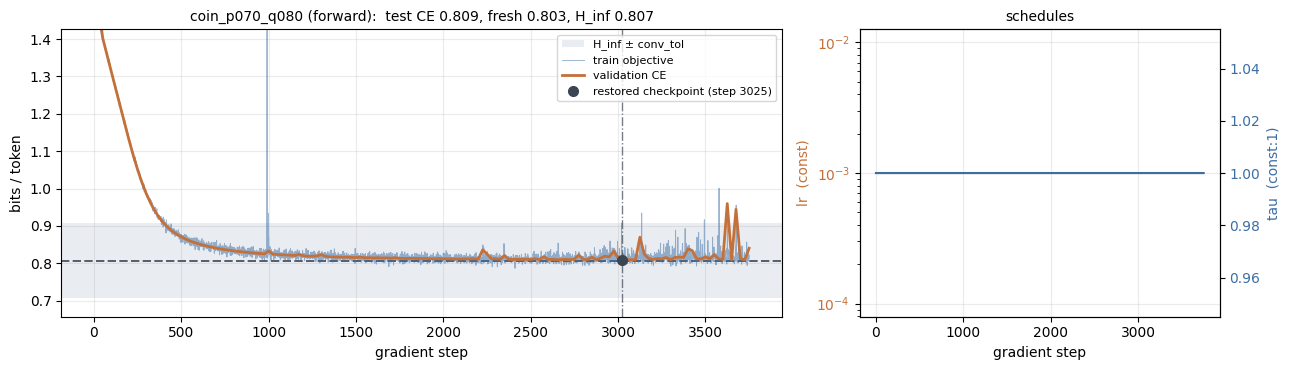

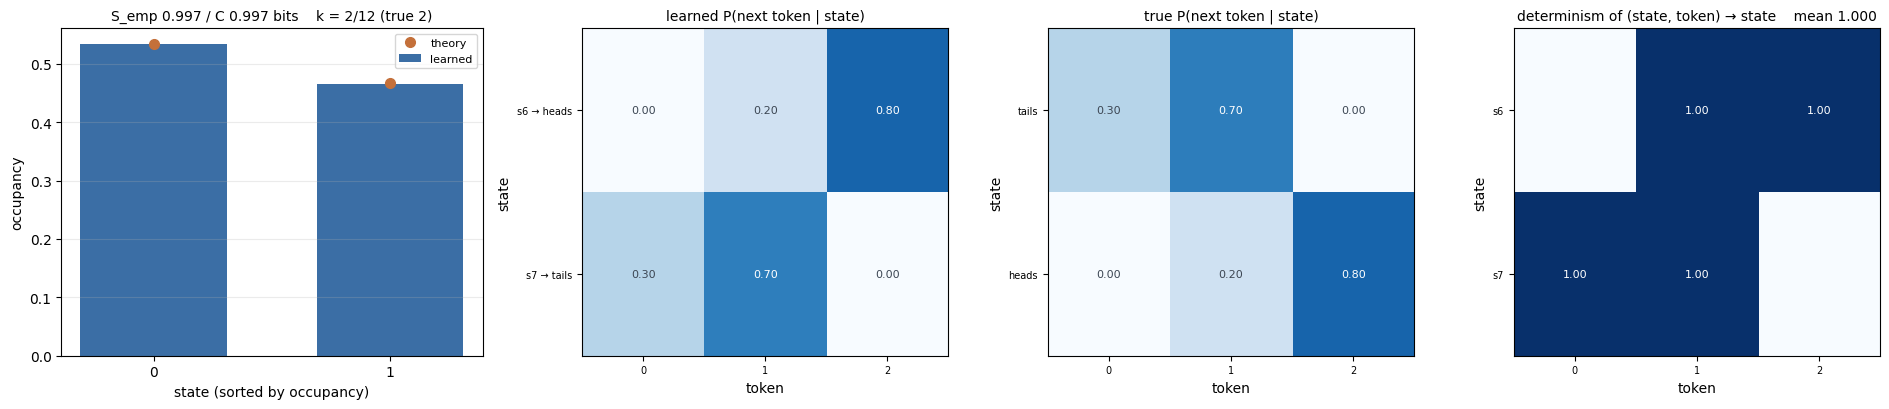

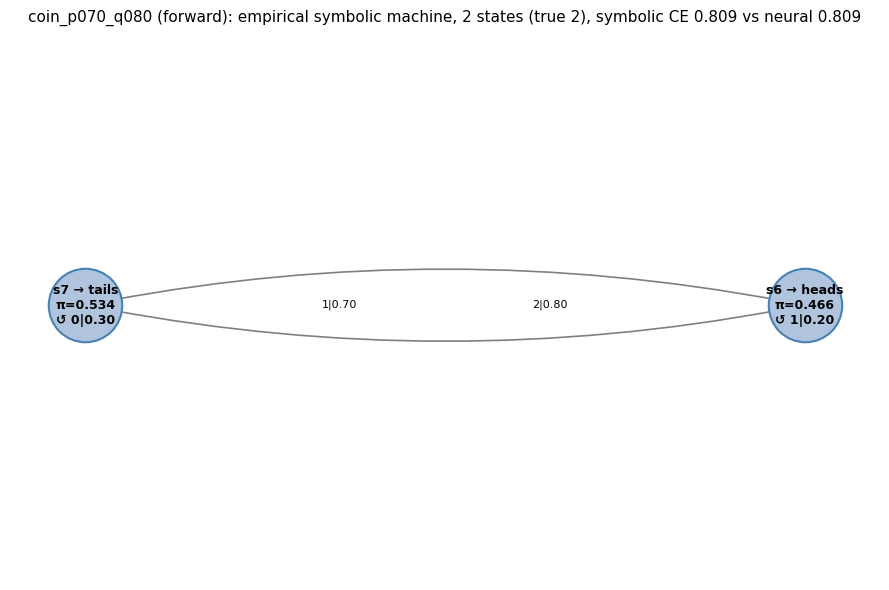

,Metric,Value
0,Test CE (bits),0.809205
1,Fresh-sequence CE (bits),0.803438
2,Entropy rate H_inf (bits),0.806922
3,CE - H_inf,0.002284
4,Converged (|CE - H_inf| <= conv_tol),True
5,Diverged after minimum,False
6,Best-val checkpoint step (fraction of run),0.806667
7,Val CE first in band (fraction of run),0.113333
8,True-machine test CE (bits),0.807134
9,Symbolic-machine test CE (bits),0.809231


In [28]:
plot_arm(coin_fw)

In [29]:
coin_bw = run_pipeline(cfg, "coin", mode="backward")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[coin_p070_q080 | backward] 1000 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau const:1 | lr 0.001 (const), wd 0.01, 150 epochs | best-val checkpoint | seed 0

==== 1) Generate observable data (coin_p070_q080 | backward arm) ====
Vocabulary size V: 3 | state budget K: 12 | state_dim S: 3 | usage_beta: 1.04e-04 | tau: 'const:1' | lr: 0.001 (const)
Sequences: 1,000 x 300 scored tokens | train 800 / test 200
Closed forms: H_inf = 0.8069 bits | C+ = 0.9968 | C- = 1.4668 | true k = 2 fw / 3 bw | this arm: C = 1.4668, k = 3

==== 2) Train the discrete transformer (backward) ====


`Trainer.fit` stopped: `max_epochs=150` reached.


Trained DiscreteCausalDecoder (47,036 parameters) in 76 s, 3750 gradient steps
Restored the best-validation checkpoint: step 2325 of 3750 (fraction 0.62), validation CE 0.809916 bits

==== 3) Evaluate against the entropy rate ====
Test CE:      0.809916 bits/token (perplexity 1.7531)
H_inf:        0.806922 bits/token (closed form)
CE - H_inf:   +0.002995  -> converged (conv_tol 0.1)
Fresh-sequence CE (100 new sequences): 0.803870 bits/token (gap -0.003052)
Validation CE first inside the H_inf band: step 450 of 3750 (fraction 0.12 of the run)
True-machine CE on the test sequences: 0.806831 bits/token

==== 4) Read the causal states off the bottleneck ====
States used: 3 / 12 (true 3)
S_emp = 1.468290 bits vs C = 1.466813 bits | H(state | token) = 0.000000 bits
Learned occupancy (visited, sorted): [0.4659 0.373  0.161 ]
Theory occupancy (sorted):           [0.4667 0.3733 0.16  ]

==== 5) Learned state-to-state transition matrix vs the closed form ====
3 states visited in generation, 3 in

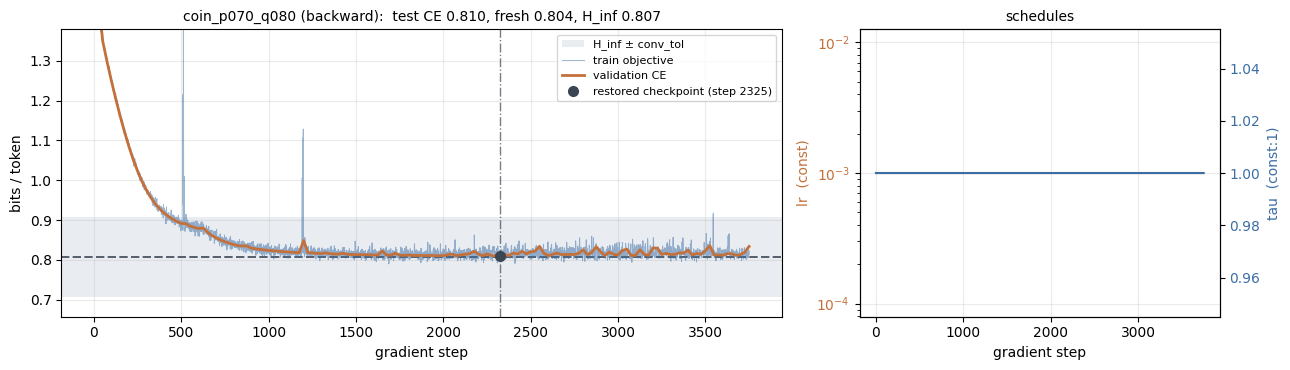

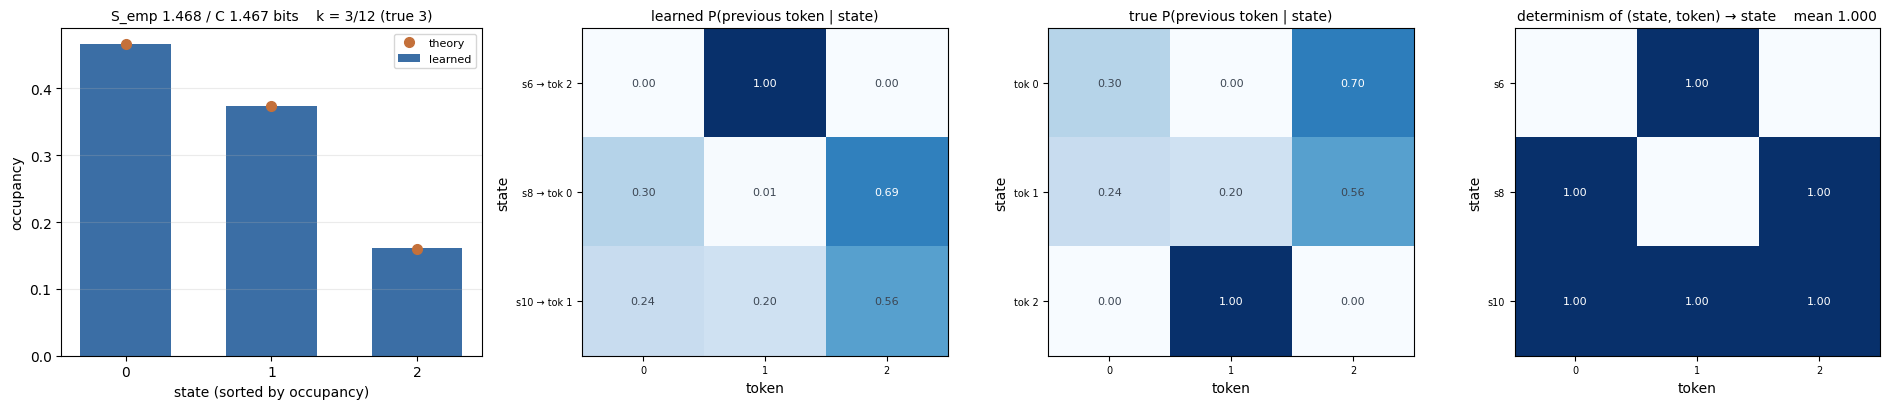

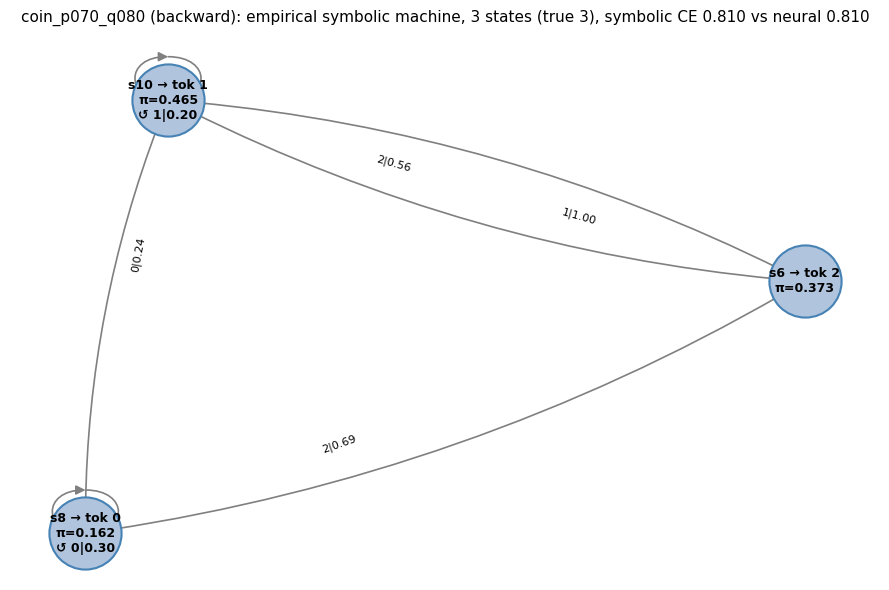

,Metric,Value
0,Test CE (bits),0.809916
1,Fresh-sequence CE (bits),0.80387
2,Entropy rate H_inf (bits),0.806922
3,CE - H_inf,0.002995
4,Converged (|CE - H_inf| <= conv_tol),True
5,Diverged after minimum,False
6,Best-val checkpoint step (fraction of run),0.62
7,Val CE first in band (fraction of run),0.12
8,True-machine test CE (bits),0.806831
9,Symbolic-machine test CE (bits),0.809555


In [30]:
plot_arm(coin_bw)

### Both arms against the closed forms

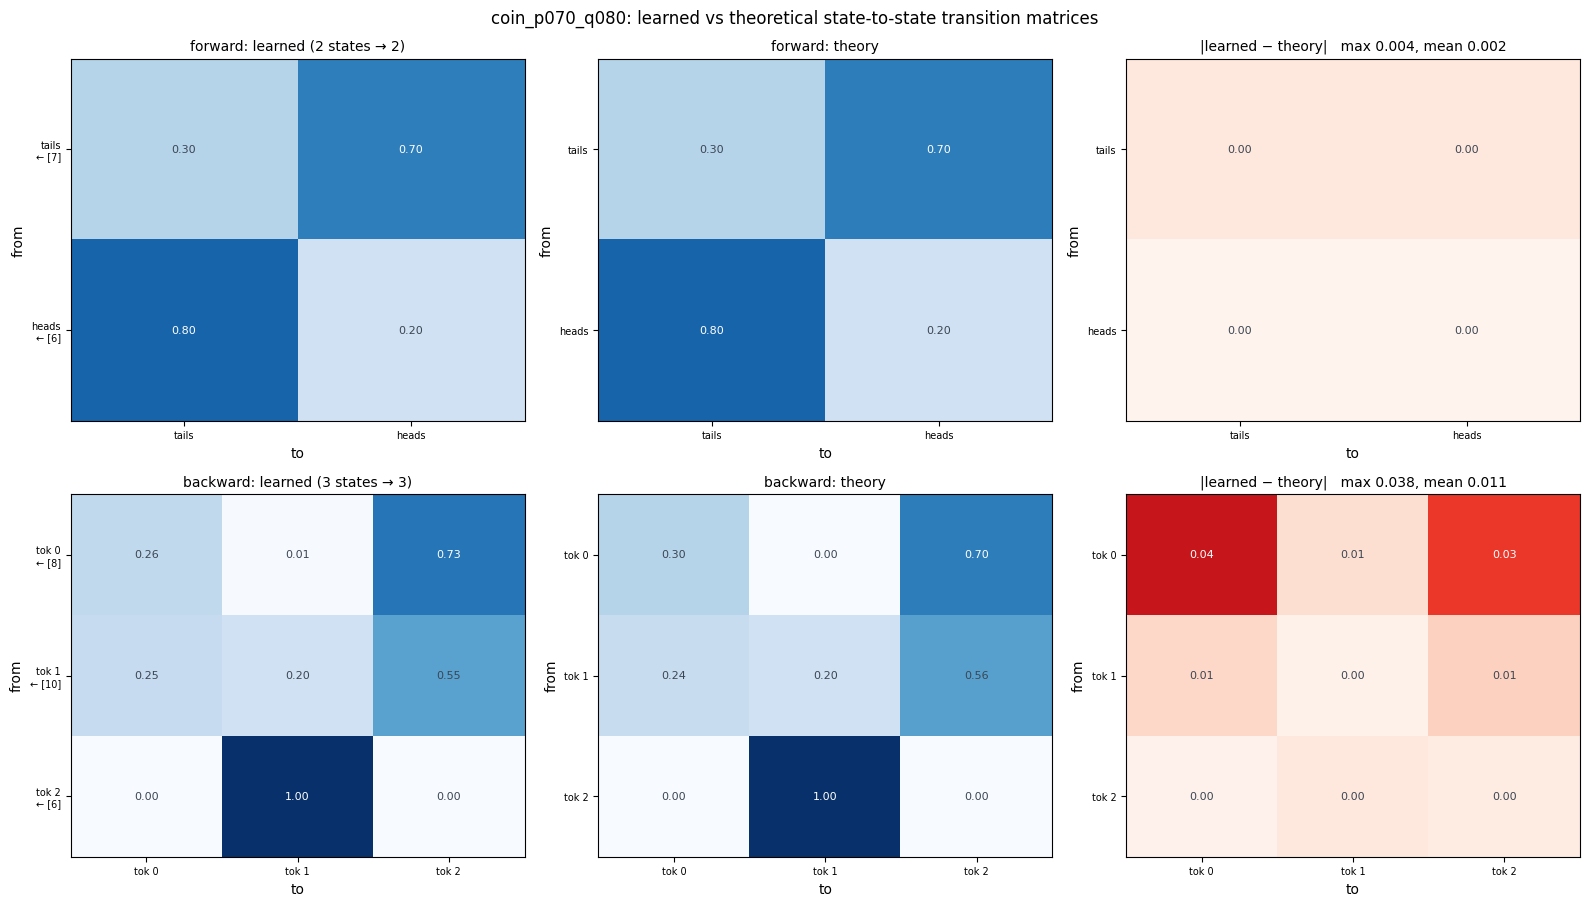

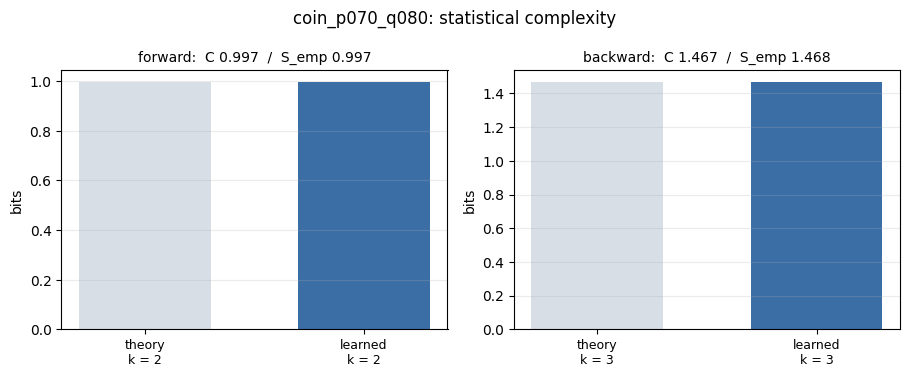

,arm,test CE (bits),fresh CE,H_inf,converged,best step,k found,true k,S_emp (bits),C (bits),S_emp - C,T max |err|,T mean |err|,T states missing
0,forward,0.809205,0.803438,0.806922,True,3025,2,2,0.996647,0.996792,-0.000145,0.004266,0.002477,0
1,backward,0.809916,0.803870,0.806922,True,2325,3,3,1.468290,1.466813,0.001477,0.038247,0.011268,0


In [31]:
coin_runs = {"forward": coin_fw, "backward": coin_bw}
plot_transition_comparison_arms(coin_runs)
plot_complexity(coin_runs)
display(arms_table(coin_runs))

## 4. Flower process  (n = 3, m = 8)

`cfg_flower = replace(cfg, max_epochs=300, tau="geom:0.5:2")`: V = 11, K = 44. Theory: forward n + 1 = 4 states (R and one per die, C+ = 1.792 bits), backward 1 + #distinguishable outcomes = 9 states (C− = 2.427 bits); H∞ = 1.981 bits. τ must rise for the forward arm to claim its 4th state (`const:1`: 0 of 12 runs; `geom:0.5:2`: 3 of 3). The backward arm finds 3–4 of its 9 states at these settings under any τ tried; the comparison reports the missing ones rather than forcing a match.

In [ ]:
cfg_flower = replace(cfg, max_epochs=500, tau="const:1",num_samples = 2500)
flower_fw = run_pipeline(cfg_flower, "flower", mode="forward")

[flower_n3_m8 | forward] 2500 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau const:1 | lr 0.001 (const), wd 0.01, 500 epochs | best-val checkpoint | seed 0

==== 1) Generate observable data (flower_n3_m8 | forward arm) ====


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Vocabulary size V: 11 | state budget K: 44 | state_dim S: 11 | usage_beta: 1.04e-04 | tau: 'const:1' | lr: 0.001 (const)
Sequences: 2,500 x 300 scored tokens | train 2,000 / test 500
Closed forms: H_inf = 1.9811 bits | C+ = 1.7925 | C- = 2.4270 | true k = 4 fw / 9 bw | this arm: C = 1.7925, k = 4

==== 2) Train the discrete transformer (forward) ====


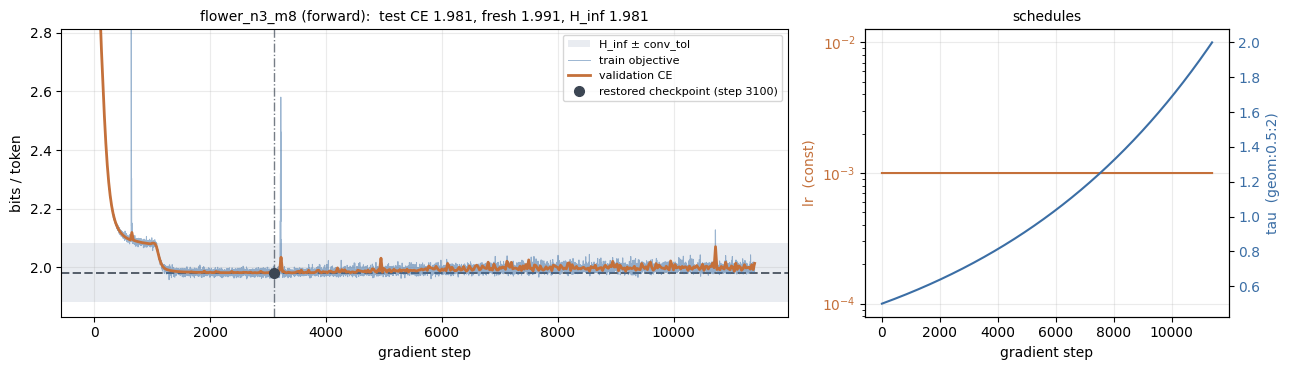

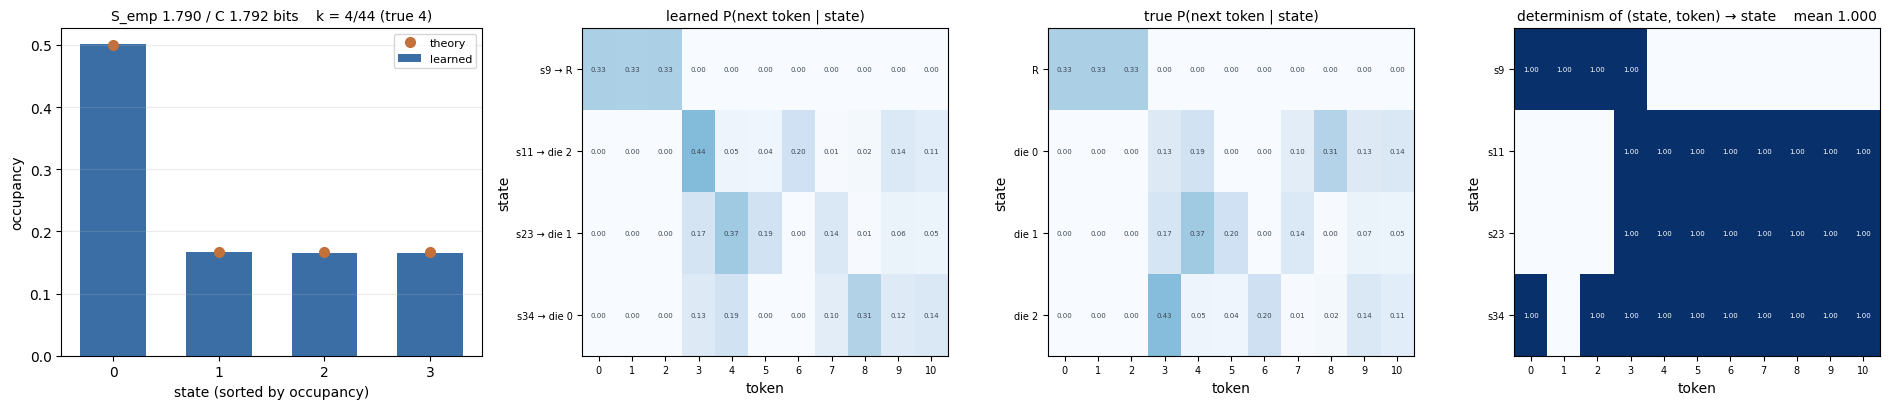

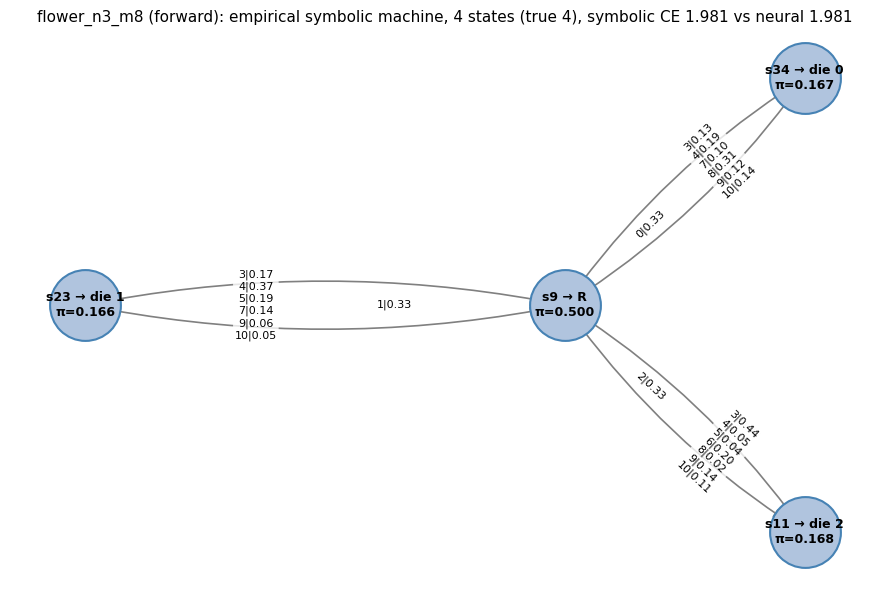

,Metric,Value
0,Test CE (bits),1.980789
1,Fresh-sequence CE (bits),1.991352
2,Entropy rate H_inf (bits),1.981129
3,CE - H_inf,-0.00034
4,Converged (|CE - H_inf| <= conv_tol),True
5,Diverged after minimum,False
6,Best-val checkpoint step (fraction of run),0.27193
7,Val CE first in band (fraction of run),0.08114
8,True-machine test CE (bits),1.979747
9,Symbolic-machine test CE (bits),1.980541


In [ ]:
plot_arm(flower_fw)

In [ ]:
cfg_flower = replace(cfg, max_epochs=500, tau="const:1",num_samples = 2500)
flower_bw = run_pipeline(cfg_flower, "flower", mode="backward")

[flower_n3_m8 | backward] 2500 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau geom:0.5:2 | lr 0.001 (const), wd 0.01, 500 epochs | best-val checkpoint | seed 0

==== 1) Generate observable data (flower_n3_m8 | backward arm) ====


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Vocabulary size V: 11 | state budget K: 44 | state_dim S: 11 | usage_beta: 1.04e-04 | tau: 'geom:0.5:2' | lr: 0.001 (const)
Sequences: 2,500 x 300 scored tokens | train 2,000 / test 500
Closed forms: H_inf = 1.9811 bits | C+ = 1.7925 | C- = 2.4270 | true k = 4 fw / 9 bw | this arm: C = 2.4270, k = 9

==== 2) Train the discrete transformer (backward) ====


`Trainer.fit` stopped: `max_epochs=500` reached.


Trained DiscreteCausalDecoder (48,660 parameters) in 809 s, 31500 gradient steps
Restored the best-validation checkpoint: step 30150 of 31500 (fraction 0.96), validation CE 1.982668 bits

==== 3) Evaluate against the entropy rate ====
Test CE:      1.982668 bits/token (perplexity 3.9522)
H_inf:        1.981129 bits/token (closed form)
CE - H_inf:   +0.001539  -> converged (conv_tol 0.1)  [DIVERGED after its minimum]
Fresh-sequence CE (100 new sequences): 1.992562 bits/token (gap +0.011433)
Validation CE first inside the H_inf band: step 1350 of 31500 (fraction 0.04 of the run)
True-machine CE on the test sequences: 1.979272 bits/token

==== 4) Read the causal states off the bottleneck ====
States used: 9 / 44 (true 9)
S_emp = 2.424516 bits vs C = 2.427045 bits | H(state | token) = 0.048282 bits
Learned occupancy (visited, sorted): [0.4983 0.127  0.1027 0.0554 0.053  0.0484 0.0409 0.0403 0.034 ]
Theory occupancy (sorted):           [0.5    0.122  0.1015 0.0555 0.0548 0.05   0.0411 0.041

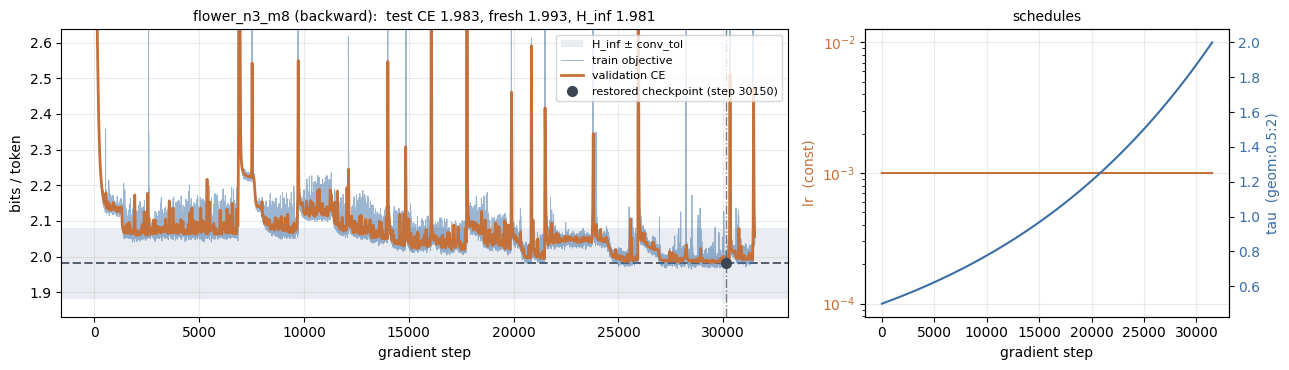

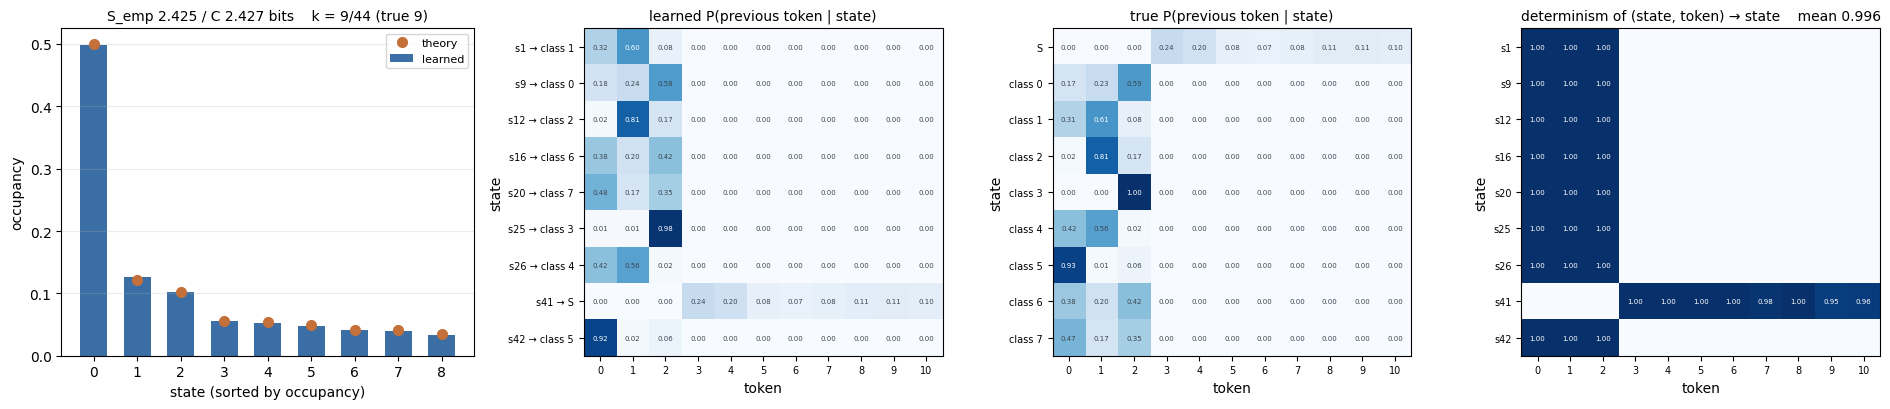

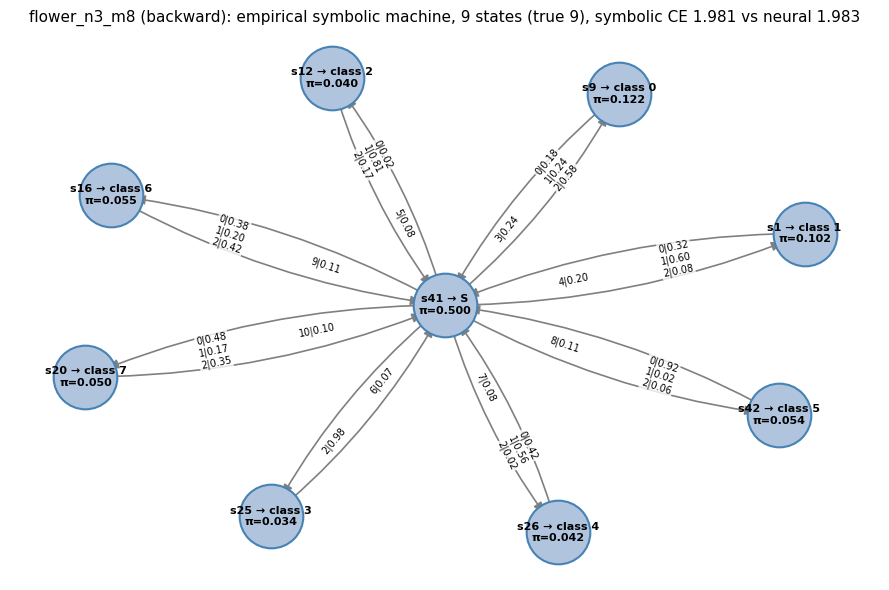

,Metric,Value
0,Test CE (bits),1.982668
1,Fresh-sequence CE (bits),1.992562
2,Entropy rate H_inf (bits),1.981129
3,CE - H_inf,0.001539
4,Converged (|CE - H_inf| <= conv_tol),True
5,Diverged after minimum,True
6,Best-val checkpoint step (fraction of run),0.957143
7,Val CE first in band (fraction of run),0.042857
8,True-machine test CE (bits),1.979272
9,Symbolic-machine test CE (bits),1.981035


In [ ]:
plot_arm(flower_bw)

### Both arms against the closed forms

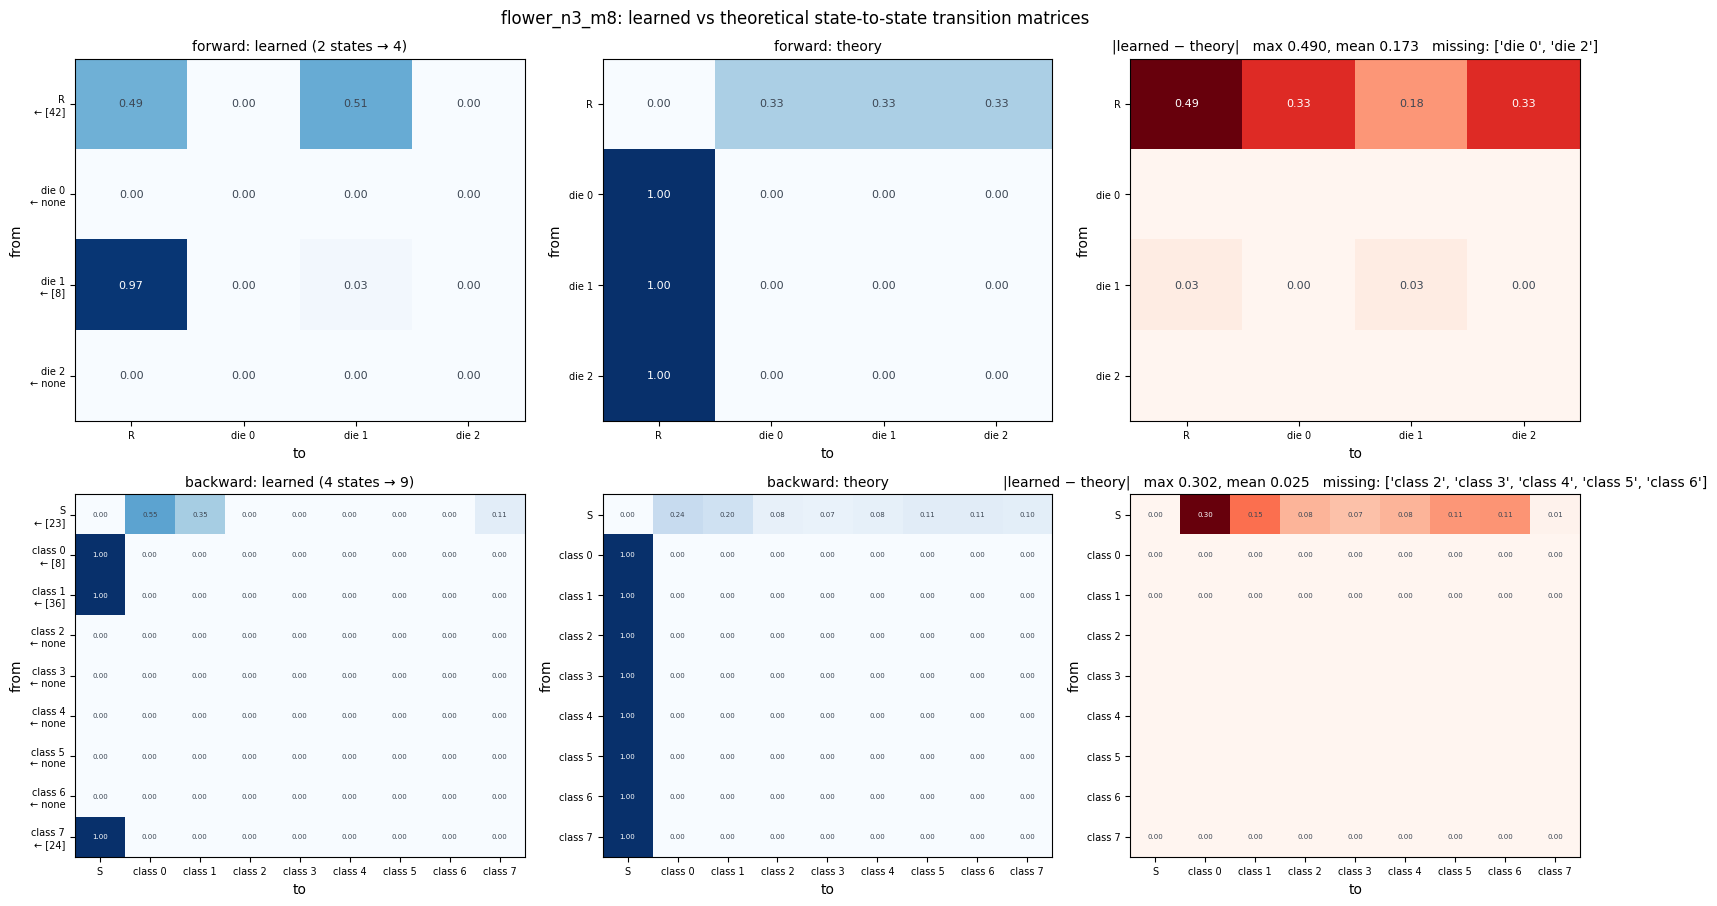

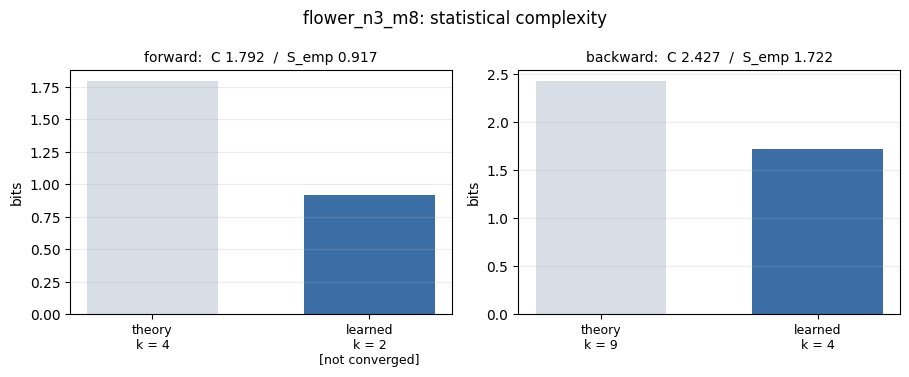

,arm,test CE (bits),fresh CE,H_inf,converged,best step,k found,true k,S_emp (bits),C (bits),S_emp - C,T max |err|,T mean |err|,T states missing
0,forward,2.678999,2.680931,1.981129,False,400,2,4,0.917423,1.792481,-0.875058,0.490399,0.17336,2
1,backward,2.060545,2.069462,1.981129,True,10975,4,9,1.722031,2.427045,-0.705013,0.302089,0.02518,5


In [43]:
flower_runs = {"forward": flower_fw, "backward": flower_bw}
plot_transition_comparison_arms(flower_runs)
plot_complexity(flower_runs)
display(arms_table(flower_runs))

## 5. Summary

In [37]:
summary = pd.concat([arms_table(coin_runs).assign(process="coin"),
                     arms_table(flower_runs).assign(process="flower")], ignore_index=True)
display(summary.set_index(["process", "arm"]))

test CE (bits)  fresh CE     H_inf  converged  best step  \
process arm                                                                  
coin    forward         0.809205  0.803438  0.806922       True       3025   
        backward        0.809916  0.803870  0.806922       True       2325   
flower  forward         1.980420  1.993473  1.981129       True       3625   
        backward        2.063907  2.070212  1.981129       True       1800   

                  k found  true k  S_emp (bits)  C (bits)  S_emp - C  \
process arm                                                            
coin    forward         2       2      0.996647  0.996792  -0.000145   
        backward        3       3      1.468290  1.466813   0.001477   
flower  forward         6       4      1.790039  1.792481  -0.002442   
        backward        4       9      1.732177  2.427045  -0.694867   

                  T max |err|  T mean |err|  T states missing  
process arm                                                    
coin    forward      0.004266      0.002477                 0  
        backward     0.038247      0.011268                 0  
flower  forward      0.035895      0.004941                 0  
        backward     0.290117      0.025990                 5

## 6. Opt-in learning-rate schedule

`lr_schedule = "cos:MIN"` decays the rate from `learning_rate` to `MIN` over the run; `"cos:MIN:HOLD"` holds it for the first `HOLD` fraction first (`schedules.parse_lr`, applied by a callback; the batch pipeline has the same knob). The idea is to start the decay only once the states are found — every run prints `Validation CE first inside the H_inf band` for that. Measured on the coin (three seeds): the forward arm is indifferent (states found at ~20 % of the run, converged either way); the backward arm is **hurt** by a cosine (`cos:1e-5` merged tok-0 into tok-1 on one seed and split a state on another, versus no merged partition on 8 seeds at a constant rate) — the decay freezes whatever partition the bottleneck is wandering through when the rate gets small. Use it with the checkpoint on and check the `S_emp` / transition rows.

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



##############################################################################
# coin: forward
##############################################################################
[coin_p070_q080 | forward] 1000 x 300 tokens, batch 32 | d_model 32, 4 layers, K = 4V, S = 1V | tau const:1 | lr 0.001 (cos:1e-5:0.25), wd 0.01, 150 epochs | best-val checkpoint | seed 0

==== 1) Generate observable data (coin_p070_q080 | forward arm) ====
Vocabulary size V: 3 | state budget K: 12 | state_dim S: 3 | usage_beta: 1.04e-04 | tau: 'const:1' | lr: 0.001 (cos:1e-5:0.25)
Sequences: 1,000 x 300 scored tokens | train 800 / test 200
Closed forms: H_inf = 0.8069 bits | C+ = 0.9968 | C- = 1.4668 | true k = 2 fw / 3 bw | this arm: C = 0.9968, k = 2

==== 2) Train the discrete transformer (forward) ====


`Trainer.fit` stopped: `max_epochs=150` reached.


Trained DiscreteCausalDecoder (47,036 parameters) in 76 s, 3750 gradient steps
Restored the best-validation checkpoint: step 3525 of 3750 (fraction 0.94), validation CE 0.810472 bits

==== 3) Evaluate against the entropy rate ====
Test CE:      0.810472 bits/token (perplexity 1.7538)
H_inf:        0.806922 bits/token (closed form)
CE - H_inf:   +0.003550  -> converged (conv_tol 0.1)
Fresh-sequence CE (100 new sequences): 0.804698 bits/token (gap -0.002224)
Validation CE first inside the H_inf band: step 425 of 3750 (fraction 0.11 of the run)
True-machine CE on the test sequences: 0.807134 bits/token

==== 4) Read the causal states off the bottleneck ====
States used: 2 / 12 (true 2)
S_emp = 0.996647 bits vs C = 0.996792 bits | H(state | token) = 0.000000 bits
Learned occupancy (visited, sorted): [0.5341 0.4659]
Theory occupancy (sorted):           [0.5333 0.4667]

==== 5) Learned state-to-state transition matrix vs the closed form ====
2 states visited in generation, 2 in theory
Learne

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Vocabulary size V: 3 | state budget K: 12 | state_dim S: 3 | usage_beta: 1.04e-04 | tau: 'const:1' | lr: 0.001 (cos:1e-5:0.25)
Sequences: 1,000 x 300 scored tokens | train 800 / test 200
Closed forms: H_inf = 0.8069 bits | C+ = 0.9968 | C- = 1.4668 | true k = 2 fw / 3 bw | this arm: C = 1.4668, k = 3

==== 2) Train the discrete transformer (backward) ====


`Trainer.fit` stopped: `max_epochs=150` reached.


Trained DiscreteCausalDecoder (47,036 parameters) in 77 s, 3750 gradient steps
Restored the best-validation checkpoint: step 2025 of 3750 (fraction 0.54), validation CE 0.811715 bits

==== 3) Evaluate against the entropy rate ====
Test CE:      0.811715 bits/token (perplexity 1.7553)
H_inf:        0.806922 bits/token (closed form)
CE - H_inf:   +0.004793  -> converged (conv_tol 0.1)
Fresh-sequence CE (100 new sequences): 0.805749 bits/token (gap -0.001173)
Validation CE first inside the H_inf band: step 450 of 3750 (fraction 0.12 of the run)
True-machine CE on the test sequences: 0.806831 bits/token

==== 4) Read the causal states off the bottleneck ====
States used: 5 / 12 (true 3)
S_emp = 2.148623 bits vs C = 1.466813 bits | H(state | token) = 0.681361 bits
Learned occupancy (visited, sorted): [0.373  0.2006 0.1953 0.1611 0.07  ]
Theory occupancy (sorted):           [0.4667 0.3733 0.16  ]

==== 5) Learned state-to-state transition matrix vs the closed form ====
5 states visited in ge

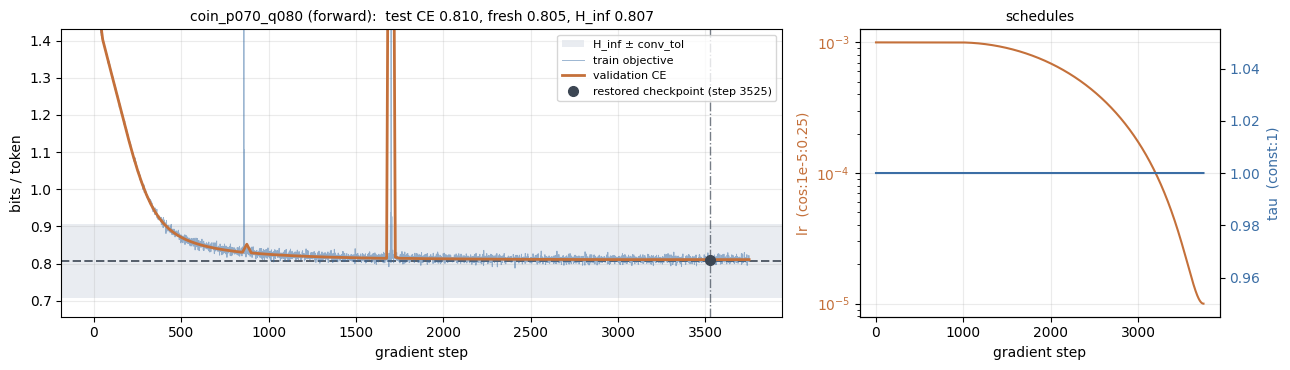

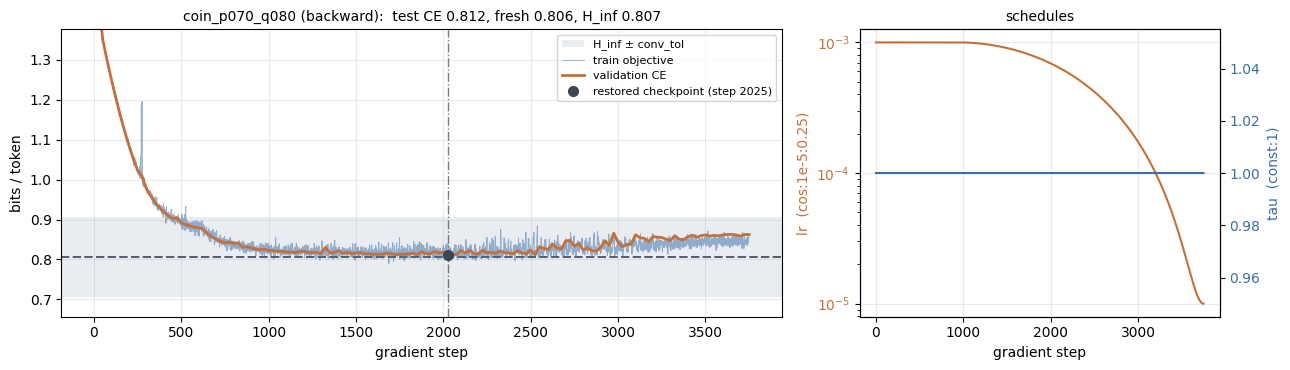

test CE (bits)  fresh CE     H_inf  converged  \
lr_schedule   arm                                                       
const         forward         0.809205  0.803438  0.806922       True   
              backward        0.809916  0.803870  0.806922       True   
cos:1e-5:0.25 forward         0.810472  0.804698  0.806922       True   
              backward        0.811715  0.805749  0.806922       True   

                        best step  k found  true k  S_emp (bits)  C (bits)  \
lr_schedule   arm                                                            
const         forward        3025        2       2      0.996647  0.996792   
              backward       2325        3       3      1.468290  1.466813   
cos:1e-5:0.25 forward        3525        2       2      0.996647  0.996792   
              backward       2025        5       3      2.148623  1.466813   

                        S_emp - C  T max |err|  T mean |err|  T states missing  
lr_schedule   arm                                                               
const         forward   -0.000145     0.004266      0.002477                 0  
              backward   0.001477     0.038247      0.011268                 0  
cos:1e-5:0.25 forward   -0.000145     0.007348      0.004451                 0  
              backward   0.681810     0.102758      0.031393                 0

In [38]:
# Both coin arms under a held-then-cosine rate, against the constant-rate runs above.
cfg_cos = replace(cfg, lr_schedule="cos:1e-5:0.25")
coin_cos = run_both_arms(cfg_cos, "coin")
for r in coin_cos.values():
    plot_training(r)
display(pd.concat([arms_table(coin_runs).assign(lr_schedule=cfg.lr_schedule),
                   arms_table(coin_cos).assign(lr_schedule=cfg_cos.lr_schedule)],
                  ignore_index=True).set_index(["lr_schedule", "arm"]))